# Week 4 Assignment: Unsupervised Classification of Sentinel-3 Altimetry Echoes

## Aims
This notebook applies **unsupervised learning** to classify **Sentinel-3 radar altimetry echoes** into two surface types:

- **Sea ice**
- **Leads** (open water within the ice pack)

The assessed outputs are:

1. **Gaussian Mixture Model (GMM)** clustering using physically meaningful echo features (**Sigma0**, **Pulse Peakiness**, **Stack Standard Deviation**).
2. **Mean echo shape ± standard deviation** for each class (**before** and **after** physical waveform alignment).
3. **Confusion matrix** comparing predicted classes against the **ESA surface-type product**.


## Get started
Mount the google drive and install the relevant packages.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install rasterio

In [ ]:
pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 108.3 MB/s eta 0:00:00


### Read in Functions Needed
Before delving into the modeling process, it's crucial to preprocess the data to ensure compatibility with our analytical models. This involves transforming the raw data into meaningful variables, such as peakniness and stack standard deviation (SSD), etc.

In [ ]:
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import numpy.ma as ma
import glob
from matplotlib.patches import Polygon
import scipy.spatial as spatial
from scipy.spatial import KDTree
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, fcluster

#SUBFUNCTIONS

#*args and **kwargs allow you to pass an unspecified number of arguments to a function,
#so when writing the function definition, you do not need to know how many arguments will be passed to your function
#**kwargs allows you to pass keyworded variable length of arguments to a function.
#You should use **kwargs if you want to handle named arguments in a function.
#double star allows us to pass through keyword arguments (and any number of them).
def peakiness(waves, **kwargs):

    "finds peakiness of waveforms."

    #print("Beginning peakiness")
    # Kwargs are:
    #          wf_plots. specify a number n: wf_plots=n, to show the first n waveform plots. \

    import numpy as np
    import matplotlib
    import matplotlib.pyplot as plt
    import time

    print("Running peakiness function...")

    size=np.shape(waves)[0] #.shape property is a tuple of length .ndim containing the length of each dimensions
                            #Tuple of array dimensions.

    waves1=np.copy(waves)

    if waves1.ndim == 1: #number of array dimensions
        print('only one waveform in file')
        waves2=waves1.reshape(1,np.size(waves1)) #numpy.reshape(a, newshape, order='C'), a=array to be reshaped
        waves1=waves2

    # *args is used to send a non-keyworded variable length argument list to the function
    def by_row(waves, *args):
        "calculate peakiness for each waveform"
        maximum=np.nanmax(waves)
        if maximum > 0:

            maximum_bin=np.where(waves==maximum)
            #print(maximum_bin)
            maximum_bin=maximum_bin[0][0]
            waves_128=waves[maximum_bin-50:maximum_bin+78]

            waves=waves_128

            noise_floor=np.nanmean(waves[10:20])
            where_above_nf=np.where(waves > noise_floor)

            if np.shape(where_above_nf)[1] > 0:
                maximum=np.nanmax(waves[where_above_nf])
                total=np.sum(waves[where_above_nf])
                mean=np.nanmean(waves[where_above_nf])
                peaky=maximum/mean

            else:
                peaky = np.nan
                maximum = np.nan
                total = np.nan

        else:
            peaky = np.nan
            maximum = np.nan
            total = np.nan

        if 'maxs' in args:
            return maximum
        if 'totals' in args:
            return total
        if 'peaky' in args:
            return peaky

    peaky=np.apply_along_axis(by_row, 1, waves1, 'peaky') #numpy.apply_along_axis(func1d, axis, arr, *args, **kwargs)

    if 'wf_plots' in kwargs:
        maximums=np.apply_along_axis(by_row, 1, waves1, 'maxs')
        totals=np.apply_along_axis(by_row, 1, waves1, 'totals')

        for i in range(0,kwargs['wf_plots']):
            if i == 0:
                print("Plotting first "+str(kwargs['wf_plots'])+" waveforms")

            plt.plot(waves1[i,:])#, a, col[i],label=label[i])
            plt.axhline(maximums[i], color='green')
            plt.axvline(10, color='r')
            plt.axvline(19, color='r')
            plt.xlabel('Bin (of 256)')
            plt.ylabel('Power')
            plt.text(5,maximums[i],"maximum="+str(maximums[i]))
            plt.text(5,maximums[i]-2500,"total="+str(totals[i]))
            plt.text(5,maximums[i]-5000,"peakiness="+str(peaky[i]))
            plt.title('waveform '+str(i)+' of '+str(size)+'\n. Noise floor average taken between red lines.')
            plt.show()


    return peaky

#=========================================================================================================

def unpack_gpod(variable):

    from scipy.interpolate import interp1d

    time_1hz=SAR_data.variables['time_01'][:]
    time_20hz=SAR_data.variables['time_20_ku'][:]
    time_20hzC = SAR_data.variables['time_20_c'][:]

    out=(SAR_data.variables[variable][:]).astype(float)  # convert from integer array to float.

    #if ma.is_masked(dataset.variables[variable][:]) == True:
    #print(variable,'is masked. Removing mask and replacing masked values with nan')
    out=np.ma.filled(out, np.nan)

    if len(out)==len(time_1hz):

        print(variable,'is 1hz. Expanding to 20hz...')
        out = interp1d(time_1hz,out,fill_value="extrapolate")(time_20hz)

    if len(out)==len(time_20hzC):
        print(variable, 'is c band, expanding to 20hz ku band dimension')
        out = interp1d(time_20hzC,out,fill_value="extrapolate")(time_20hz)
    return out


#=========================================================================================================

def calculate_SSD(RIP):

    from scipy.optimize import curve_fit
    # from scipy import asarray as ar,exp
    from numpy import asarray as ar, exp

    do_plot='Off'

    def gaussian(x,a,x0,sigma):
            return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

    SSD=np.zeros(np.shape(RIP)[0])*np.nan
    x=np.arange(np.shape(RIP)[1])

    for i in range(np.shape(RIP)[0]):

        y=np.copy(RIP[i])
        y[(np.isnan(y)==True)]=0

        if 'popt' in locals():
            del(popt,pcov)

        SSD_calc=0.5*(np.sum(y**2)*np.sum(y**2)/np.sum(y**4))
        #print('SSD calculated from equation',SSD)

        #n = len(x)
        mean_est = sum(x * y) / sum(y)
        sigma_est = np.sqrt(sum(y * (x - mean_est)**2) / sum(y))
        #print('est. mean',mean,'est. sigma',sigma_est)

        try:
            popt,pcov = curve_fit(gaussian, x, y, p0=[max(y), mean_est, sigma_est],maxfev=10000)
        except RuntimeError as e:
            print("Gaussian SSD curve-fit error: "+str(e))
            #plt.plot(y)
            #plt.show()

        except TypeError as t:
            print("Gaussian SSD curve-fit error: "+str(t))

        if do_plot=='ON':

            plt.plot(x,y)
            plt.plot(x,gaussian(x,*popt),'ro:',label='fit')
            plt.axvline(popt[1])
            plt.axvspan(popt[1]-popt[2], popt[1]+popt[2], alpha=0.15, color='Navy')
            plt.show()

            print('popt',popt)
            print('curve fit SSD',popt[2])

        if 'popt' in locals():
            SSD[i]=abs(popt[2])


    return SSD


# Altimetry Echo Classification (Sentinel-3)

The next sections explore the application of these unsupervised methods to altimetry classification tasks, focusing specifically on distinguishing between sea ice and leads in Sentinel-3 altimetry dataset.

The procedure comprises the following steps:

1. **Data Ingestion** - Load Sentinel-3 radar waveforms together with ESA surface-type labels, restricting the dataset to the ice–lead subset.

2. **Feature Construction** - Derive physically interpretable echo descriptors (Sigma0, Pulse Peakiness (PP) and Stack Standard Deviation (SSD)) to represent each waveform in a reduced feature space.

3. **Unsupervised Clustering** - Fit a two-component Gaussian Mixture Model (primary method) and a K-means model (baseline comparison), then assign physical meaning to clusters based on feature statistics.

4. **Quantitative Evaluation** - Compare predicted classes with ESA reference labels using confusion matrices and classification metrics.

5. **Waveform Characterisation and Alignment** - Compute mean ± standard deviation waveforms for each class and assess the impact of physically based alignment on peak structure and class separation.


In [ ]:
# User parameters (edit these)

# Path to the folder that contains the .SEN3 directory
path = '/content/drive/MyDrive/Week_4_AI4EO/'

# Sentinel-3 product directory name (the .SEN3 folder)
SAR_file = 'S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3'

# Reproducibility
RANDOM_STATE = 0


### Sentinel-3 Data Loading and Feature Construction

This section loads the Sentinel-3 Level-2 SAR altimetry product and constructs a physically interpretable feature space for unsupervised classification.

The following variables are extracted from the `enhanced_measurement.nc` file:

*   `waveform_20_ku` → 256-bin radar echoes
*   `sig0_water_20_ku` → backscatter coefficient (Sigma0)
*   `rip_20_ku` → range integrated power
*   `surf_type_class_20_ku` → ESA surface classification labels
*   Geographic coordinates (lat/lon) - Invalid measurements are removed using a latitude threshold (e.g. `lat ≥ -99999`) to eliminate fill values and corrupted records.

The helper function `unpack_gpod()` expands variables to the 20 Hz dimension where required.

In [ ]:
SAR_data = Dataset(path + SAR_file + '/enhanced_measurement.nc')

SAR_lat = unpack_gpod('lat_20_ku')
SAR_lon = unpack_gpod('lon_20_ku')
waves   = unpack_gpod('waveform_20_ku')
sig_0   = unpack_gpod('sig0_water_20_ku')
RIP     = unpack_gpod('rip_20_ku')
flag = unpack_gpod('surf_type_class_20_ku')

# Filter out bad data points using criteria (here, lat >= -99999)
find = np.where(SAR_lat >= -99999)
SAR_lat = SAR_lat[find]
SAR_lon = SAR_lon[find]
waves   = waves[find]
sig_0   = sig_0[find]
RIP     = RIP[find]

# Calculate additional features
PP = peakiness(waves)
SSD = calculate_SSD(RIP)

# Convert to numpy arrays
sig_0_np = np.array(sig_0)
PP_np    = np.array(PP)
SSD_np   = np.array(SSD)

# Create data matrix
data = np.column_stack((sig_0_np, PP_np, SSD_np))

# Standardize the data
scaler = StandardScaler()
data_normalized = scaler.fit_transform(data)

Running peakiness function...


/tmp/ipython-input-336166544.py:60: RuntimeWarning: Mean of empty slice
  noise_floor=np.nanmean(waves[10:20])


Gaussian SSD curve-fit error: Optimal parameters not found: Number of calls to function has reached maxfev = 10000.
Gaussian SSD curve-fit error: Optimal parameters not found: Number of calls to function has reached maxfev = 10000.
Gaussian SSD curve-fit error: Optimal parameters not found: Number of calls to function has reached maxfev = 10000.


There are some NaN values in the dataset so one way to deal with this is to delete them.

Feature extraction and Gaussian fitting introduce some NaN values, primarily due to:

*   Waveforms with insufficient valid bins for peakiness estimation
*   RIP signals that cannot be reliably fitted with a Gaussian when computing SSD

Rather than attempting imputation, rows containing any NaN across the feature space are removed. This ensures:

*   The clustering algorithm operates on finite numerical values only
*   All features remain physically meaningful
*   No artificial bias is introduced through interpolation

In [ ]:
# Data cleaning and filtering

# Count NaNs introduced by feature calculation / standardisation
nan_count = np.isnan(data_normalized).sum()
print(f"Number of NaN values in the array: {nan_count}")

# Mask valid (finite) rows across all three features
mask = ~np.isnan(data_normalized).any(axis=1)

# Apply the mask consistently to:
# - normalised feature matrix (for clustering)
# - raw waveforms (for mean/SD plotting)
# - ESA surface-type flag (for validation)
data_cleaned = data_normalized[mask]
waves_cleaned = np.array(waves)[mask]
flag_cleaned  = np.array(flag)[mask]

# Also keep the *original (un-normalised)* feature values for interpretation
sig0_cleaned = np.array(sig_0_np)[mask]
PP_cleaned   = np.array(PP_np)[mask]
SSD_cleaned  = np.array(SSD_np)[mask]

# Restrict to the two ESA surface classes used in this practical:
# ESA convention in this dataset: sea ice = 1, lead = 2
ice_lead = (flag_cleaned == 1) | (flag_cleaned == 2)

data_cleaned   = data_cleaned[ice_lead]
waves_cleaned  = waves_cleaned[ice_lead]
flag_cleaned   = flag_cleaned[ice_lead]
sig0_cleaned   = sig0_cleaned[ice_lead]
PP_cleaned     = PP_cleaned[ice_lead]
SSD_cleaned    = SSD_cleaned[ice_lead]

print(f"Remaining samples (ESA ice/lead only): {len(flag_cleaned)}")


Number of NaN values in the array: 1283
Remaining samples (ESA ice/lead only): 12195


The code below will run the GMM model. This can be substituted with K-Means or any other preferred model.

In [ ]:
# GMM clustering (2 components)
gmm = GaussianMixture(n_components=2, random_state=RANDOM_STATE)
gmm.fit(data_cleaned)

# Raw cluster IDs are arbitrary (0/1) — we map them to physical classes below
clusters_gmm = gmm.predict(data_cleaned)


## Map clusters to physical classes (Sea ice vs Lead)

In unsupervised learning, cluster IDs (0/1) have **no inherent meaning**.  

Physical meaning is assigned using the interpretation that **leads are more specular**, producing **higher pulse peakiness** than rough sea ice.

The cluster with the **higher mean pulse peakiness** is mapped to **Lead (1)**; the other is mapped to **Sea ice (0)**.


In [ ]:
# Compute summary statistics by cluster for interpretation
for k in [0, 1]:
    k_mask = clusters_gmm == k
    print(f"Cluster {k}: n={np.sum(k_mask)} | mean(PP)={np.nanmean(PP_cleaned[k_mask]):.3f} | "
          f"mean(sig0)={np.nanmean(sig0_cleaned[k_mask]):.3f} | mean(SSD)={np.nanmean(SSD_cleaned[k_mask]):.3f}")

# Assign clusters to physical labels using pulse peakiness
lead_cluster = int(np.nanargmax([np.nanmean(PP_cleaned[clusters_gmm==0]), np.nanmean(PP_cleaned[clusters_gmm==1])]))
ice_cluster  = 1 - lead_cluster

print(f"Assigned: Lead = cluster {lead_cluster} (higher pulse peakiness), Sea ice = cluster {ice_cluster}")

# Create physically-labelled predictions following the ESA recoded convention:
# 0 = Sea ice, 1 = Lead
predicted_labels = np.zeros_like(clusters_gmm, dtype=int)
predicted_labels[clusters_gmm == lead_cluster] = 1


Cluster 0: n=8880 | mean(PP)=6.536 | mean(sig0)=11.350 | mean(SSD)=36.682
Cluster 1: n=3315 | mean(PP)=28.660 | mean(sig0)=26.020 | mean(SSD)=4.626
Assigned: Lead = cluster 1 (higher pulse peakiness), Sea ice = cluster 0


The amount of data points in each class of the clustering prediction can be inspected below.

In [ ]:
# Inspect number of points per predicted physical class
unique, counts = np.unique(predicted_labels, return_counts=True)
class_counts = dict(zip(unique, counts))
print("Class counts (0 = sea ice, 1 = lead):", class_counts)


Class counts (0 = sea ice, 1 = lead): {np.int64(0): np.int64(8880), np.int64(1): np.int64(3315)}


This plots the mean waveform of each class.

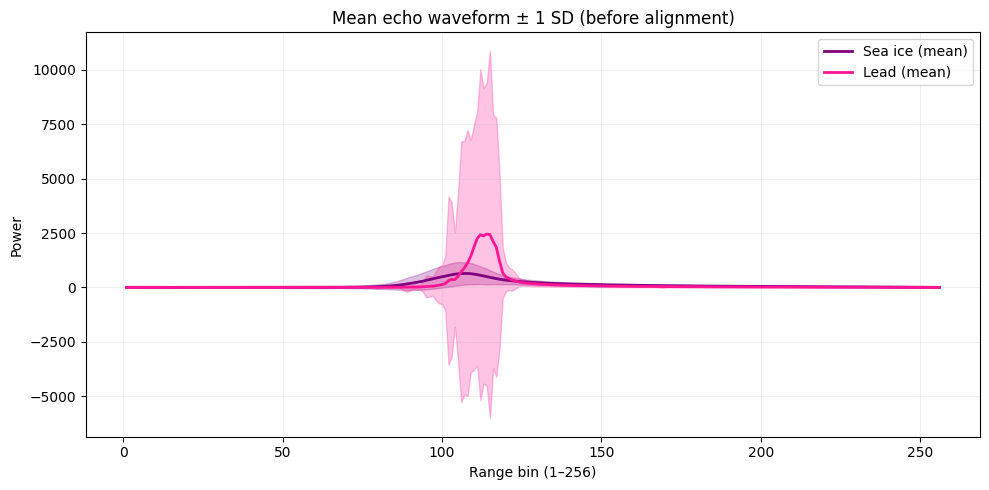

In [ ]:
# Mean waveform ± standard deviation (BEFORE alignment)

# Sea ice = 0, Lead = 1
mean_ice = np.mean(waves_cleaned[predicted_labels == 0], axis=0)
std_ice  = np.std(waves_cleaned[predicted_labels == 0],  axis=0)

mean_lead = np.mean(waves_cleaned[predicted_labels == 1], axis=0)
std_lead  = np.std(waves_cleaned[predicted_labels == 1],  axis=0)

x = np.arange(1, waves_cleaned.shape[1] + 1)

plt.figure(figsize=(10, 5))

# Sea ice = Purple
plt.plot(x, mean_ice, color='purple', linewidth=2, label='Sea ice (mean)')
plt.fill_between(
    x,
    mean_ice - std_ice,
    mean_ice + std_ice,
    color='purple',
    alpha=0.25)

# Lead = Pink
plt.plot(x, mean_lead, color='deeppink', linewidth=2, label='Lead (mean)')
plt.fill_between(
    x,
    mean_lead - std_lead,
    mean_lead + std_lead,
    color='deeppink',
    alpha=0.25)

plt.title('Mean echo waveform ± 1 SD (before alignment)')
plt.xlabel('Range bin (1–256)')
plt.ylabel('Power')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/mean_echo_waveform_before_alignment.png", dpi=300, bbox_inches="tight")
plt.show()

### Visual Inspection of Individual Echoes

To examine waveform variability within the dataset, a small random subset of echoes are plotted for both lead and sea ice.

Here, a fixed number of echoes (up to 10) are selected without replacement to provide a representative visual sample.

Random sampling ensures:

*   The selection is unbiased
*   Individual waveform structure remains visible

The plotted curves illustrate the typical echo shape across range bins, including:

*   The leading edge
*   The peak location
*   The trailing decay

These plots complement the quantitative analysis (mean ± standard deviation), allowing visual confirmation of waveform variability and consistency within the dataset.

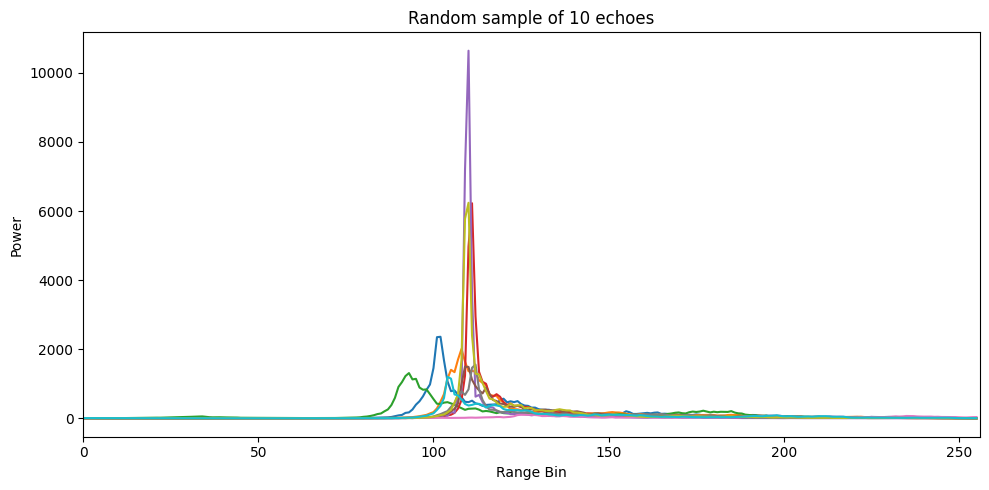

In [ ]:
# Plot 10 random echoes
n_show = min(10, waves_cleaned.shape[0])

# Randomly select indices without replacement
random_idx = np.random.choice(
    waves_cleaned.shape[0],
    size=n_show,
    replace=False)

# Extract random echoes
waves_sample = waves_cleaned[random_idx]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(waves_sample.T)
plt.xlabel("Range Bin")
plt.ylabel("Power")
plt.title(f"Random sample of {n_show} echoes")
plt.xlim(0, waves_cleaned.shape[1])
plt.tight_layout()
plt.show()

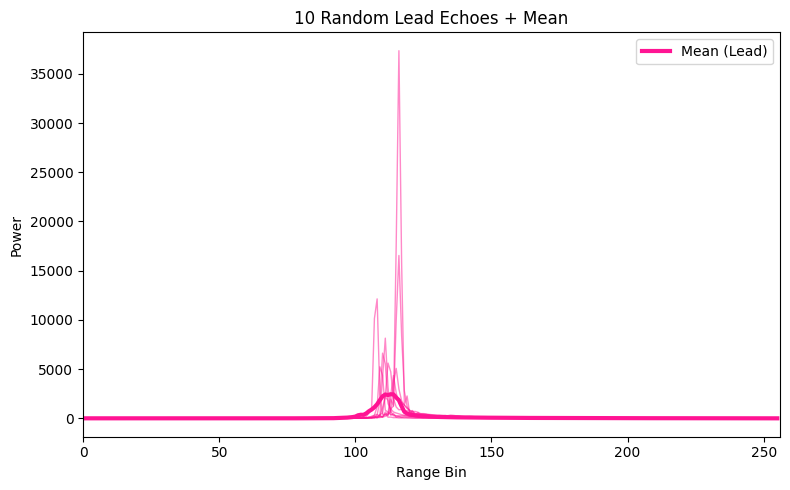

In [ ]:
# Plot 10 random Lead echoes with mean overlay

lead_waves = waves_cleaned[clusters_gmm == 1]

n_show = min(10, lead_waves.shape[0])

np.random.seed(42)  # reproducibility
random_idx = np.random.choice(lead_waves.shape[0], size=n_show, replace=False)

lead_sample = lead_waves[random_idx]
lead_mean = np.mean(lead_waves, axis=0)

plt.figure(figsize=(8, 5))

# Individual echoes
plt.plot(lead_sample.T, color='deeppink', alpha=0.5, linewidth=1)

# Mean waveform
plt.plot(lead_mean, color='deeppink', linewidth=3, label='Mean (Lead)')

plt.xlabel("Range Bin")
plt.ylabel("Power")
plt.title(f"{n_show} Random Lead Echoes + Mean")
plt.xlim(0, lead_waves.shape[1])
plt.legend()
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/lead_echos.png", dpi=300, bbox_inches="tight")
plt.show()

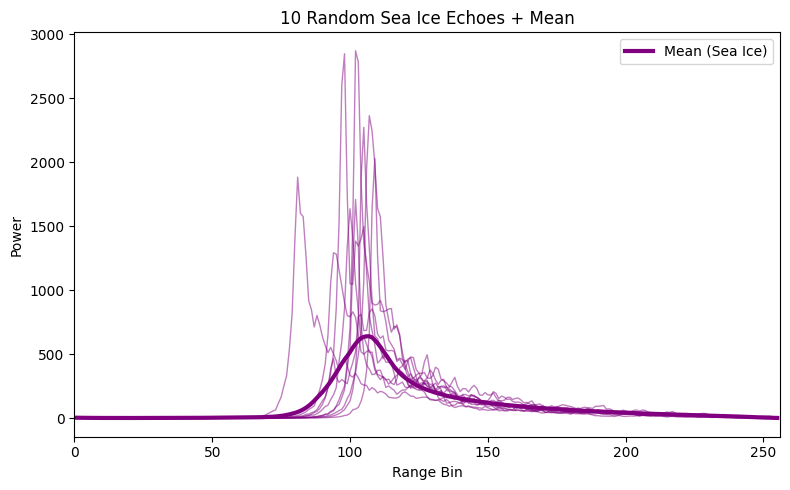

In [ ]:
# Plot 10 random Sea Ice echoes with mean overlay

sea_ice_waves = waves_cleaned[clusters_gmm == 0]

n_show = min(10, sea_ice_waves.shape[0])

np.random.seed(42)  # reproducibility
random_idx = np.random.choice(sea_ice_waves.shape[0], size=n_show, replace=False)

sea_ice_sample = sea_ice_waves[random_idx]
sea_ice_mean = np.mean(sea_ice_waves, axis=0)

plt.figure(figsize=(8, 5))

# Individual echoes (faint)
plt.plot(sea_ice_sample.T, color='purple', alpha=0.5, linewidth=1)

# Mean waveform (bold)
plt.plot(sea_ice_mean, color='purple', linewidth=3, label='Mean (Sea Ice)')

plt.xlabel("Range Bin")
plt.ylabel("Power")
plt.title(f"{n_show} Random Sea Ice Echoes + Mean")
plt.xlim(0, sea_ice_waves.shape[1])
plt.legend()
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/sea_ice_echos.png", dpi=300, bbox_inches="tight")
plt.show()

## Scatter Plots of Clustered Data

To interpret the Gaussian Mixture Model results, the clustered echoes are visualised within the standardised three-dimensional feature space using scatter plots.

Each echo is represented by its feature vector:

*   Sigma0 (backscatter intensity)
*   Pulse Peakiness (PP)
*   Stack Standard Deviation (SSD)

The predicted class labels are displayed using a discrete colour scheme where different colors represent different clusters (`clusters_gmm`):

*   Sea ice (0) → purple
*   Lead (1) → pink


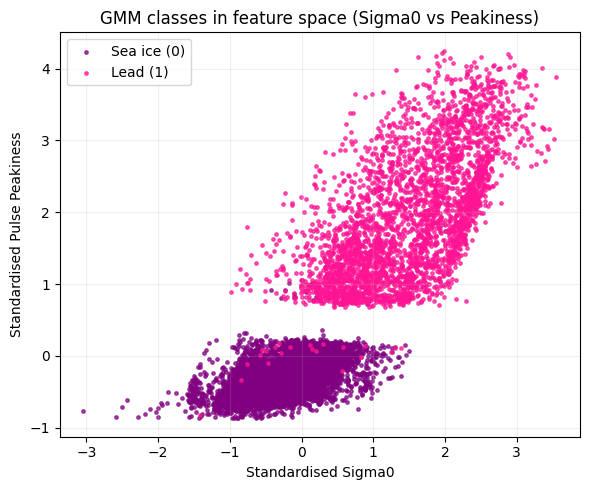

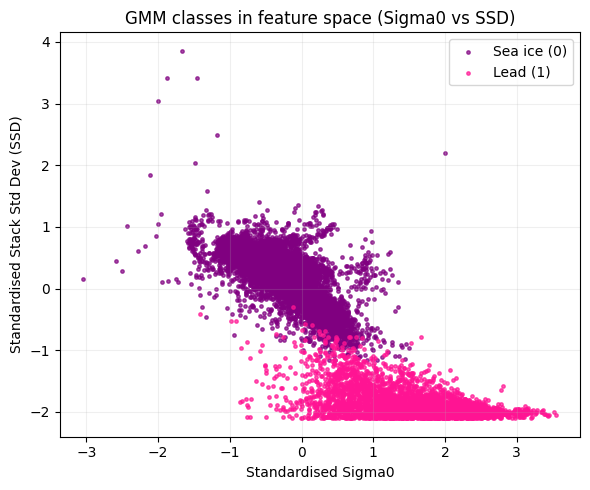

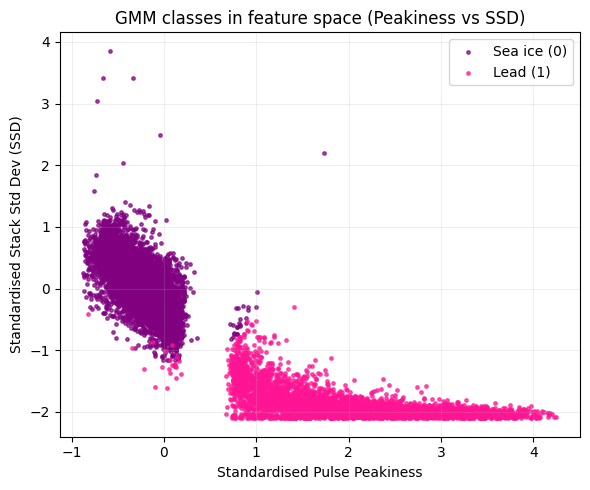

In [ ]:
# Visualise clustering in feature space (colour = predicted class)
# Sea ice = 0 (purple), Lead = 1 (pink)

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# Discrete two-colour map: index 0 -> purple, index 1 -> pink
cmap_pp = ListedColormap(['purple', 'deeppink'])

def scatter_by_class(x, y, xlabel, ylabel, title):
    plt.figure(figsize=(6, 5))

    # Plot each class separately so we can create a clean legend
    for cls, name, color in [(0, "Sea ice (0)", "purple"), (1, "Lead (1)", "deeppink")]:
        m = predicted_labels == cls
        plt.scatter(x[m], y[m], s=6, alpha=0.7, c=color, label=name)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()

# Sigma0 vs Peakiness
scatter_by_class(data_cleaned[:, 0], data_cleaned[:, 1],
    "Standardised Sigma0", "Standardised Pulse Peakiness",
    "GMM classes in feature space (Sigma0 vs Peakiness)")

# Sigma0 vs SSD
scatter_by_class(data_cleaned[:, 0], data_cleaned[:, 2],
    "Standardised Sigma0", "Standardised Stack Std Dev (SSD)",
    "GMM classes in feature space (Sigma0 vs SSD)")

# Peakiness vs SSD
scatter_by_class(data_cleaned[:, 1], data_cleaned[:, 2],
    "Standardised Pulse Peakiness", "Standardised Stack Std Dev (SSD)",
    "GMM classes in feature space (Peakiness vs SSD)")

## Physical Waveform Alignment

Radar altimetry waveforms are not inherently aligned in range space.
Small shifts can arise due to:

*   Internal tracking window jitter
*   Atmospheric propagation delays
*   Variations in satellite altitude
*   Geophysical range corrections
*   Mean sea surface reference offsets

If waveforms are averaged without correcting for these effects, the leading edge becomes artificially broadened and peak structure is smeared. This can distort the physical interpretation of class-mean echo shapes.

To compare waveforms on a common footing, these are aligned using the known orbit geometry. This physically-based approach was developed at the [Alfred Wegener Institute (AWI)](https://gitlab.awi.de/siteo/aligned-waveform-generator).



In [ ]:
# Physical Waveform Alignment (AWI-style)

from scipy.interpolate import interp1d

# Step 1: Read alignment variables from the NetCDF file
print("Reading alignment variables...")
tracker_range_all = unpack_gpod('tracker_range_20_ku')
altitude_all      = unpack_gpod('alt_20_ku')
mss_all           = unpack_gpod('mean_sea_surf_sol1_20_ku')

# Sum atmospheric and geophysical range corrections (1 Hz → 20 Hz).
# We use a dedicated interpolation that filters NaN before fitting,
# because unpack_gpod can fail on masked 1 Hz arrays in newer SciPy.
correction_names = [
    'mod_dry_tropo_cor_zero_altitude_01',
    'mod_wet_tropo_cor_zero_altitude_01',
    'iono_cor_gim_01_ku',
    'ocean_tide_sol1_01',
    'load_tide_sol1_01',
    'pole_tide_01',
    'solid_earth_tide_01',]

def safe_interp_1hz(var_name, n_20hz):
    """Read a 1 Hz variable and interpolate to 20 Hz, handling NaN."""
    vals = np.array(SAR_data.variables[var_name][:], dtype=float)
    if hasattr(vals, 'filled'):
        vals = np.ma.filled(vals, np.nan)
    time_1hz  = np.array(SAR_data.variables['time_01'][:], dtype=float)
    time_20hz = np.array(SAR_data.variables['time_20_ku'][:], dtype=float)
    valid = ~np.isnan(vals)
    if np.sum(valid) < 2:
        return np.zeros(n_20hz)
    f = interp1d(time_1hz[valid], vals[valid], kind='linear',
                 fill_value='extrapolate')
    return f(time_20hz)

n_20hz = len(tracker_range_all)
total_correction_all = np.zeros(n_20hz)
for name in correction_names:
    try:
        total_correction_all += safe_interp_1hz(name, n_20hz)
    except Exception as e:
        print(f"  Skipping {name}: {e}")

# Step 2: Apply the same filters used for waves_cleaned
# (find → NaN mask → sea-ice/lead flag filter)
_flag_filt = np.array(flag)[find][mask]
ice_lead_filt = (_flag_filt == 1) | (_flag_filt == 2)

tracker_range_c = tracker_range_all[find][mask][ice_lead_filt]
altitude_c      = altitude_all[find][mask][ice_lead_filt]
mss_c           = mss_all[find][mask][ice_lead_filt]
correction_c    = total_correction_all[find][mask][ice_lead_filt]

# Step 3: Compute the alignment shift for each waveform
alignment_m = altitude_c - tracker_range_c - correction_c - mss_c

print(f"\nRaw alignment shifts ({len(alignment_m)} waveforms):")
print(f"  Mean:  {np.nanmean(alignment_m):.3f} m")
print(f"  Std:   {np.nanstd(alignment_m):.3f} m")
print(f"  Range: [{np.nanmin(alignment_m):.3f}, {np.nanmax(alignment_m):.3f}] m")

# Clip outliers: shifts far from the bulk arise from poor MSS or
# correction data at high latitudes.  Keep the central 98 %.
finite = np.isfinite(alignment_m)
p1, p99 = np.nanpercentile(alignment_m[finite], [1, 99])
outlier = (~finite) | (alignment_m < p1) | (alignment_m > p99)
alignment_m[outlier] = 0.0

# Remove the mean offset so we only correct for *differential* alignment.
# The mean shift is dominated by average freeboard / MSS bias, not by
# waveform-to-waveform tracker variation.
nonzero = alignment_m != 0
alignment_m[nonzero] -= np.mean(alignment_m[nonzero])

print(f"After clipping + de-meaning ({np.sum(outlier)} outliers zeroed):")
print(f"  Std:   {np.nanstd(alignment_m):.3f} m")

# Step 4: Define alignment helper functions
RANGE_GATE_RES = 0.2342   # metres per range bin (Sentinel-3 Ku-band)

def fft_oversample(waveform, factor):
    """Oversample a waveform using FFT zero-padding."""
    n = len(waveform)
    n_os = n * factor
    ft = np.fft.fftshift(np.fft.fft(np.nan_to_num(waveform)))
    pad = int(np.floor(n_os / 2 - n / 2))
    ft_padded = np.concatenate([np.zeros(pad), ft, np.zeros(pad)])
    return np.real(np.fft.ifft(np.fft.fftshift(ft_padded))) * n_os / n

def align_single_waveform(waveform, shift_m, n_bins, resolution, os_factor):
    """Shift a single waveform by shift_m metres via FFT oversampling."""
    wf_os = fft_oversample(waveform, os_factor)
    x_m = np.linspace(0, n_bins * resolution, len(wf_os), endpoint=False)
    shifted = np.interp(x_m + shift_m, x_m, wf_os)
    return shifted[::os_factor]          # decimate back to original bins

# Step 5: Normalise and align all cleaned waveforms
n_bins = waves_cleaned.shape[1]
os_factor = int(np.ceil(RANGE_GATE_RES * 100))   # ~24x for ~1 cm resolution

# Per-waveform normalisation to [0, 1]
wf_max = np.nanmax(waves_cleaned, axis=1, keepdims=True).astype(float)
wf_max[wf_max == 0] = 1
waves_norm = waves_cleaned / wf_max

print(f"\nAligning {len(waves_norm)} waveforms (oversample x{os_factor}) ...")
waves_aligned = np.zeros_like(waves_norm)
for i in range(len(waves_norm)):
    shift = alignment_m[i]
    if np.isnan(shift):
        shift = 0.0
    waves_aligned[i] = align_single_waveform(
        waves_norm[i], shift, n_bins, RANGE_GATE_RES, os_factor)

# Quick summary: peak-position improvement
peaks_before = np.argmax(waves_norm, axis=1)
peaks_after  = np.argmax(waves_aligned, axis=1)
print(f"\nPeak position std:   {np.std(peaks_before):.2f}  ->  {np.std(peaks_after):.2f} bins")

Reading alignment variables...

Raw alignment shifts (12195 waveforms):
  Mean:  4.169 m
  Std:   3.739 m
  Range: [-27.545, 76.854] m
After clipping + de-meaning (2934 outliers zeroed):
  Std:   1.897 m

Aligning 12195 waveforms (oversample x24) ...

Peak position std:   10.77  ->  8.19 bins


### Effect of alignment on individual waveforms
To illustrate the impact of physical alignment at the individual-echo level, selected waveforms are compared before and after range correction.

Rather than plotting arbitrary examples, the waveforms with the **largest finite alignment shifts** are selected. This ensures that the effect of alignment is clearly visible and not masked by near-zero corrections.

Three sea-ice echoes and three lead echoes are chosen to provide balanced representation across surface types.



<>:51: SyntaxWarning: invalid escape sequence '\d'
<>:51: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-1423229109.py:51: SyntaxWarning: invalid escape sequence '\d'
  f'{cls_name}  ($\delta$ = {shift_val:.2f} m / {shift_bins:.1f} bins)',


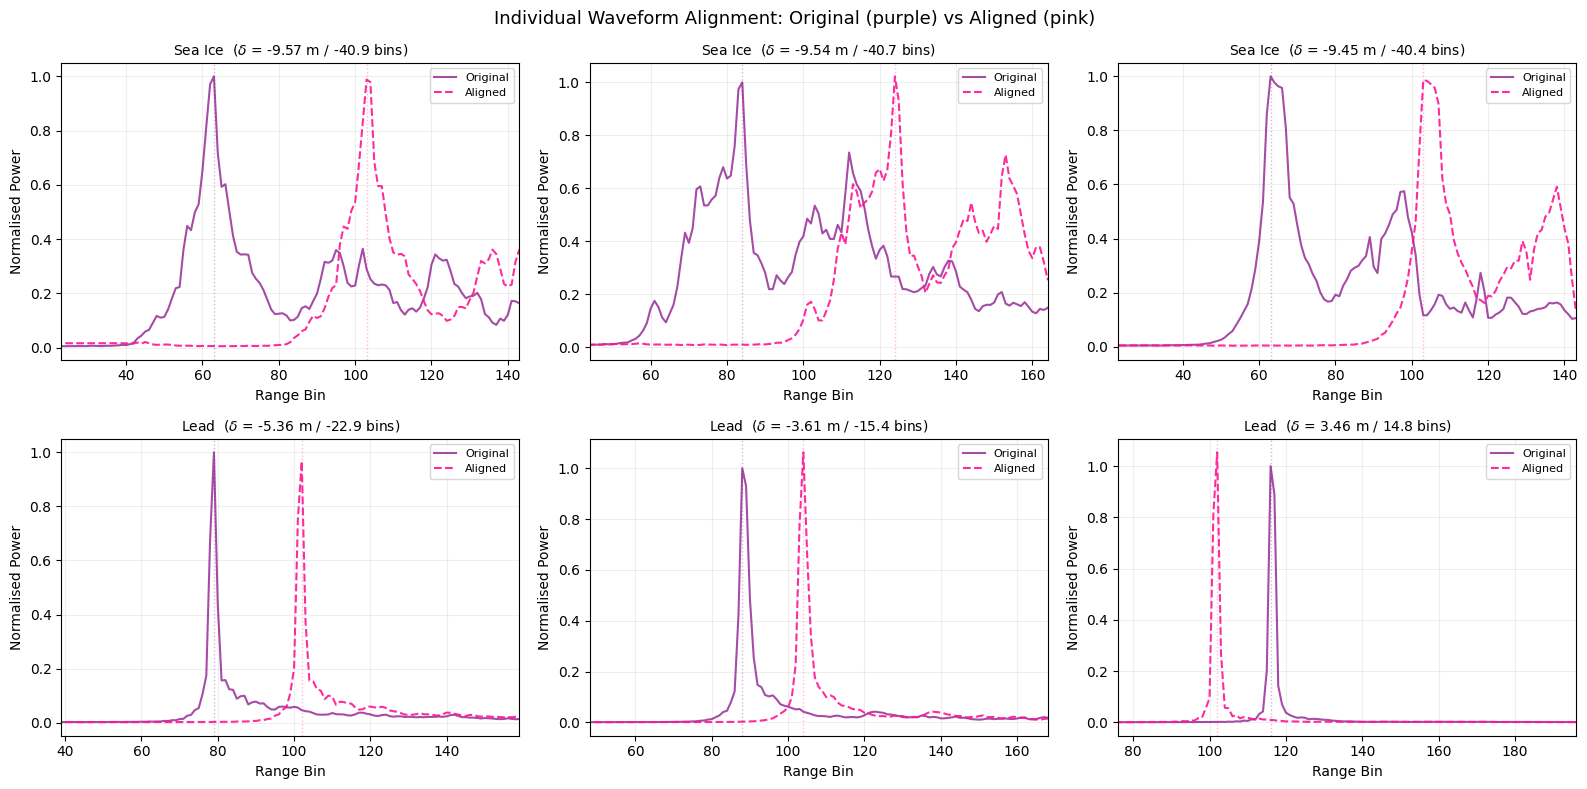

In [ ]:
# Individual waveform comparison: before vs after alignment

abs_shifts = np.abs(alignment_m)
has_shift  = np.isfinite(alignment_m) & (abs_shifts > 0)

# Pick the 3 sea-ice and 3 lead waveforms with the largest finite shifts
ice_valid  = np.where((predicted_labels == 0) & has_shift)[0]
lead_valid = np.where((predicted_labels == 1) & has_shift)[0]

ice_top3  = ice_valid[np.argsort(abs_shifts[ice_valid])[::-1][:3]]
lead_top3 = lead_valid[np.argsort(abs_shifts[lead_valid])[::-1][:3]]
show_idx  = np.concatenate([ice_top3, lead_top3])

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
x = np.arange(n_bins)

for i, idx in enumerate(show_idx):
    ax = axes[i // 3, i % 3]

    # Purple
    ax.plot(
        x,
        waves_norm[idx],
        color='purple',
        alpha=0.7,
        linewidth=1.5,
        label='Original')

    # Pink
    ax.plot(
        x,
        waves_aligned[idx],
        color='deeppink',
        linestyle='--',
        alpha=0.9,
        linewidth=1.5,
        label='Aligned')

    # Mark peak positions
    pk_orig  = np.argmax(waves_norm[idx])
    pk_align = np.argmax(waves_aligned[idx])

    ax.axvline(pk_orig,  color='purple', alpha=0.3, linewidth=1.0, linestyle=':')
    ax.axvline(pk_align, color='deeppink', alpha=0.3, linewidth=1.0, linestyle=':')

    cls_name  = 'Sea Ice' if predicted_labels[idx] == 0 else 'Lead'
    shift_val = alignment_m[idx]
    shift_bins = shift_val / RANGE_GATE_RES

    ax.set_title(
        f'{cls_name}  ($\delta$ = {shift_val:.2f} m / {shift_bins:.1f} bins)',
        fontsize=10)

    ax.set_xlabel('Range Bin')
    ax.set_ylabel('Normalised Power')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.2)

    # Zoom to leading-edge region
    ax.set_xlim(max(0, pk_orig - 40), min(n_bins, pk_orig + 80))

plt.suptitle(
    'Individual Waveform Alignment: Original (purple) vs Aligned (pink)',
    fontsize=13)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/effect_of_alignment.png", dpi=300, bbox_inches="tight")
plt.show()

### Aggregate alignment comparison

The figure below summarises the alignment effect across **all** waveforms:

- **Top row** - Echogram before and after alignment. A tighter bright band indicates better alignment.
- **Bottom left** - histogram of peak positions. The aligned distribution (pink) should be narrower.
- **Bottom right** - mean waveform per class. After alignment the mean leading edge becomes sharper because individual waveforms are better registered.

<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3266644213.py:27: SyntaxWarning: invalid escape sequence '\s'
  label=f'Before ($\sigma$={np.std(peaks_before):.1f} bins)')
/tmp/ipython-input-3266644213.py:29: SyntaxWarning: invalid escape sequence '\s'
  label=f'After ($\sigma$={np.std(peaks_after):.1f} bins)')


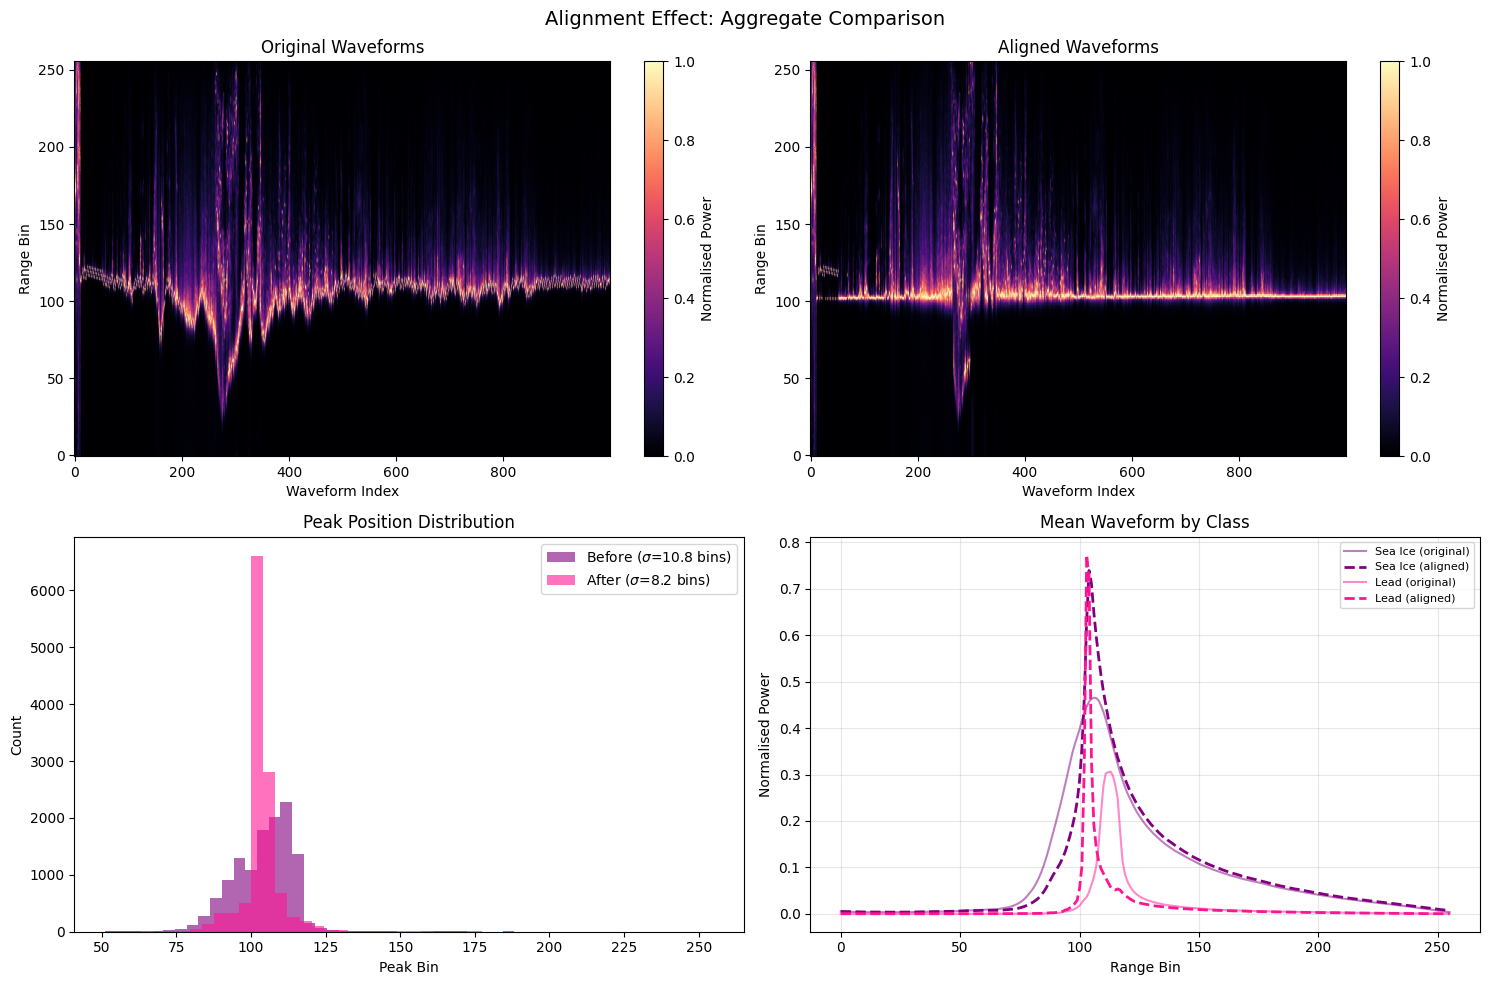

In [ ]:
# Aggregate alignment comparison

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
n_img = min(1000, len(waves_norm))

# --- Top left: original waveform image ---
ax = axes[0, 0]
im = ax.imshow(waves_norm[:n_img].T, origin='lower', aspect='auto',
               cmap='magma', vmin=0, vmax=1)
ax.set_title('Original Waveforms')
ax.set_xlabel('Waveform Index')
ax.set_ylabel('Range Bin')
plt.colorbar(im, ax=ax, label='Normalised Power')

# --- Top right: aligned waveform image ---
ax = axes[0, 1]
im = ax.imshow(waves_aligned[:n_img].T, origin='lower', aspect='auto',
               cmap='magma', vmin=0, vmax=1)
ax.set_title('Aligned Waveforms')
ax.set_xlabel('Waveform Index')
ax.set_ylabel('Range Bin')
plt.colorbar(im, ax=ax, label='Normalised Power')

# --- Bottom left: peak position histograms ---
ax = axes[1, 0]
ax.hist(peaks_before, bins=50, alpha=0.6, color='purple',
        label=f'Before ($\sigma$={np.std(peaks_before):.1f} bins)')
ax.hist(peaks_after,  bins=50, alpha=0.6, color='deeppink',
        label=f'After ($\sigma$={np.std(peaks_after):.1f} bins)')
ax.set_xlabel('Peak Bin')
ax.set_ylabel('Count')
ax.set_title('Peak Position Distribution')
ax.legend()

# --- Bottom right: mean waveform by class, before vs after ---
ax = axes[1, 1]
xr = np.arange(n_bins)
for cls, name, color in [(0, 'Sea Ice', 'purple'), (1, 'Lead', 'deeppink')]:
    cls_mask = predicted_labels == cls
    if np.sum(cls_mask) < 5:
        continue
    ax.plot(xr, np.nanmean(waves_norm[cls_mask], axis=0),
            color=color, linestyle='-', alpha=0.5, label=f'{name} (original)')
    ax.plot(xr, np.nanmean(waves_aligned[cls_mask], axis=0),
            color=color, linestyle='--', linewidth=2, label=f'{name} (aligned)')
ax.set_xlabel('Range Bin')
ax.set_ylabel('Normalised Power')
ax.set_title('Mean Waveform by Class')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Alignment Effect: Aggregate Comparison', fontsize=14)
plt.tight_layout()
plt.show()

## Mean echo shape ± standard deviation (after alignment)

After physically aligning echoes, the **mean waveform** and **standard deviation** is recomputed for each class.  
Alignment should sharpen the mean leading edge by reducing bin-to-bin peak jitter across the ensemble.


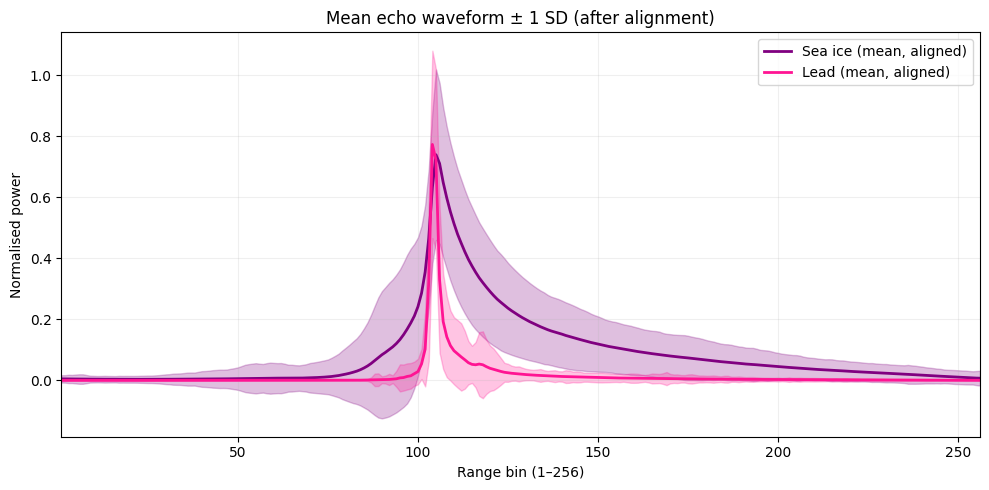

In [ ]:
# Mean waveform ± standard deviation (AFTER alignment)

mean_ice_a = np.mean(waves_aligned[predicted_labels == 0], axis=0)
std_ice_a  = np.std(waves_aligned[predicted_labels == 0],  axis=0)

mean_lead_a = np.mean(waves_aligned[predicted_labels == 1], axis=0)
std_lead_a  = np.std(waves_aligned[predicted_labels == 1],  axis=0)

x = np.arange(1, waves_aligned.shape[1] + 1)

plt.figure(figsize=(10, 5))

# Sea Ice = Purple
plt.plot(
    x,
    mean_ice_a,
    color='purple',
    linewidth=2,
    label='Sea ice (mean, aligned)')
plt.fill_between(
    x,
    mean_ice_a - std_ice_a,
    mean_ice_a + std_ice_a,
    color='purple',
    alpha=0.25)

# Lead = Pink
plt.plot(
    x,
    mean_lead_a,
    color='deeppink',
    linewidth=2,
    label='Lead (mean, aligned)')
plt.fill_between(
    x,
    mean_lead_a - std_lead_a,
    mean_lead_a + std_lead_a,
    color='deeppink',
    alpha=0.25)

plt.title('Mean echo waveform ± 1 SD (after alignment)')
plt.xlabel('Range bin (1–256)')
plt.ylabel('Normalised power')
plt.xlim(1, 256)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/mean_echo_waveform_after_alignment.png", dpi=300, bbox_inches="tight")
plt.show()


# Compare with ESA data
In the ESA dataset, surface types are encoded as **sea ice = 1 and lead = 2**. To ensure direct comparability with the predicted class labels (0 and 1), the ESA labels are shifted by **subtracting 1**, resulting in a **consistent binary convention** (**0 = sea ice, 1 = lead**).

## Gaussian Mixture Model Classification and Validation: ESA vs GMM
This section performs unsupervised classification using a two-component Gaussian Mixture Model (GMM) and evaluates the resulting clusters against ESA surface-type labels. ESA flag recoding is handled in the confusion-matrix cell below.

GMM cluster interpretation:
  Cluster 0: n=8880 | mean(PP)=6.536 | mean(sig0)=11.350 | mean(SSD)=36.682
  Cluster 1: n=3315 | mean(PP)=28.660 | mean(sig0)=26.020 | mean(SSD)=4.626
  => Assigned Lead cluster (higher mean PP): 1


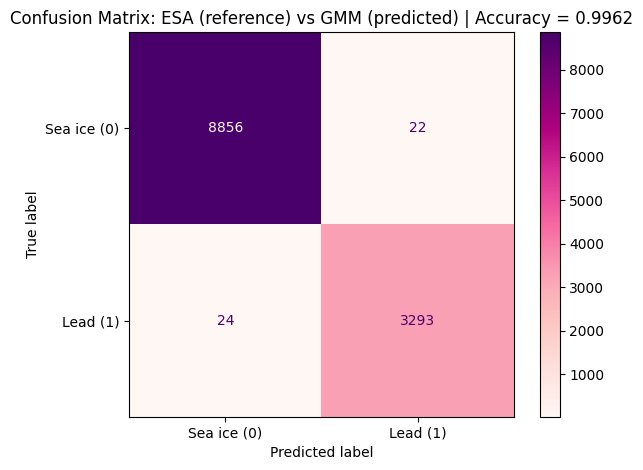

GMM Confusion Matrix:
 [[8856   22]
 [  24 3293]]

GMM Classification Report:
               precision    recall  f1-score   support

     Sea ice       1.00      1.00      1.00      8878
        Lead       0.99      0.99      0.99      3317

    accuracy                           1.00     12195
   macro avg       1.00      1.00      1.00     12195
weighted avg       1.00      1.00      1.00     12195



In [ ]:
# GMM classification (K = 2 components)

from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import os

# Recreate ESA true labels (0 = sea ice, 1 = lead)
true_labels = (flag_cleaned - 1).astype(int)

# Fit GMM on the same normalised feature matrix
gmm = GaussianMixture(n_components=2, random_state=RANDOM_STATE)
clusters_gmm = gmm.fit_predict(data_cleaned)

# Map cluster IDs to physical classes using pulse peakiness:
# the more specular class (higher mean PP) is interpreted as Lead
mean_pp_by_cluster = [np.nanmean(PP_cleaned[clusters_gmm == k]) for k in [0, 1]]
lead_cluster_gmm = int(np.nanargmax(mean_pp_by_cluster))
pred_labels_gmm = (clusters_gmm == lead_cluster_gmm).astype(int)  # 1 = Lead, 0 = Sea ice

print("GMM cluster interpretation:")
for k in [0, 1]:
    k_mask = clusters_gmm == k
    print(
        f"  Cluster {k}: n={np.sum(k_mask)} | mean(PP)={np.nanmean(PP_cleaned[k_mask]):.3f} | "
        f"mean(sig0)={np.nanmean(sig0_cleaned[k_mask]):.3f} | mean(SSD)={np.nanmean(SSD_cleaned[k_mask]):.3f}"
    )
print(f"  => Assigned Lead cluster (higher mean PP): {lead_cluster_gmm}")

# Evaluate vs ESA labels
cm_gmm = confusion_matrix(true_labels, pred_labels_gmm)
acc_gmm = np.mean(true_labels == pred_labels_gmm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_gmm, display_labels=["Sea ice (0)", "Lead (1)"])
disp.plot(cmap="RdPu", values_format="d")
plt.title(f"Confusion Matrix: ESA (reference) vs GMM (predicted) | Accuracy = {acc_gmm:.4f}")
plt.tight_layout()

# Save figure
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/confusion_matrix_GMM.png", dpi=300, bbox_inches="tight")
plt.show()

print("GMM Confusion Matrix:\n", cm_gmm)
print("\nGMM Classification Report:\n", classification_report(true_labels, pred_labels_gmm, target_names=["Sea ice", "Lead"]))

## Compact comparison: K-means vs ESA (binary ice/lead)

**K-means** was introduced as a simple hard-clustering baseline and **GMM** as a more flexible probabilistic alternative.
Here, K-means (K=2) is applied to the **same standardised feature set** and evaluated against ESA labels, using the **same cluster → class mapping rule** (higher **Pulse Peakiness** → **Lead**).

K-means cluster interpretation:
  Cluster 0: n=8947 | mean(PP)=6.609 | mean(sig0)=11.360 | mean(SSD)=36.539
  Cluster 1: n=3248 | mean(PP)=28.917 | mean(sig0)=26.295 | mean(SSD)=4.358
  => Assigned Lead cluster (higher mean PP): 1


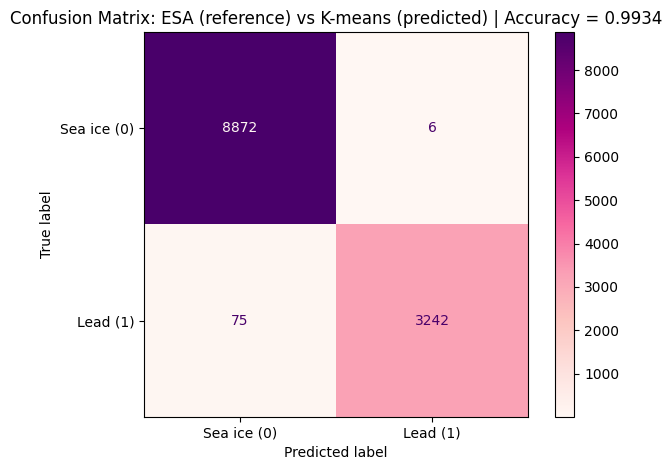

K-means Confusion Matrix:
 [[8872    6]
 [  75 3242]]

K-means Classification Report:
               precision    recall  f1-score   support

     Sea ice       0.99      1.00      1.00      8878
        Lead       1.00      0.98      0.99      3317

    accuracy                           0.99     12195
   macro avg       0.99      0.99      0.99     12195
weighted avg       0.99      0.99      0.99     12195



In [ ]:
# K-means baseline (K = 2)

from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import os

# Recreate ESA true labels (0 = sea ice, 1 = lead)
true_labels = (flag_cleaned - 1).astype(int)

# Fit K-means on the same normalised feature matrix used for GMM
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
clusters_km = kmeans.fit_predict(data_cleaned)

# Map cluster IDs to physical classes using pulse peakiness:
# the more specular class (higher mean PP) is interpreted as Lead
mean_pp_by_cluster = [np.nanmean(PP_cleaned[clusters_km == k]) for k in [0, 1]]
lead_cluster_km = int(np.nanargmax(mean_pp_by_cluster))
pred_labels_km = (clusters_km == lead_cluster_km).astype(int)  # 1 = Lead, 0 = Sea ice

print("K-means cluster interpretation:")
for k in [0, 1]:
    k_mask = clusters_km == k
    print(
        f"  Cluster {k}: n={np.sum(k_mask)} | mean(PP)={np.nanmean(PP_cleaned[k_mask]):.3f} | "
        f"mean(sig0)={np.nanmean(sig0_cleaned[k_mask]):.3f} | mean(SSD)={np.nanmean(SSD_cleaned[k_mask]):.3f}"
    )
print(f"  => Assigned Lead cluster (higher mean PP): {lead_cluster_km}")

# Evaluate vs ESA labels
cm_km = confusion_matrix(true_labels, pred_labels_km)
acc_km = np.mean(true_labels == pred_labels_km)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_km, display_labels=["Sea ice (0)", "Lead (1)"])
disp.plot(cmap="RdPu", values_format="d")
plt.title(f"Confusion Matrix: ESA (reference) vs K-means (predicted) | Accuracy = {acc_km:.4f}")
plt.tight_layout()

# Save figure
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/confusion_matrix_kmeans.png", dpi=300, bbox_inches="tight")
plt.show()

print("K-means Confusion Matrix:\n", cm_km)
print("\nK-means Classification Report:\n", classification_report(true_labels, pred_labels_km, target_names=["Sea ice", "Lead"]))